# DS Lab Assignment 7 — Frequency Distributions, Central Tendency, Variability & Correlation

**Name**: Debarun Ghosh  
**Student ID**: 25MDA294  
**Date**: 05 June 2026

In [1]:
# Common imports used throughout this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Question 1 — Grouped Frequency Distribution of Exam Scores

**Dataset:**
```
Scores = [45, 52, 61, 70, 68, 74, 81, 56, 49, 65, 72, 59, 63, 77, 84, 67, 73, 58,
          62, 69, 75, 80, 54, 47, 66, 71, 64, 60, 57, 78]
```

**Tasks:**
1. Create a grouped frequency distribution with class intervals of 10.
2. Display the frequency table.
3. Plot a histogram of the data.

In [2]:
scores = [45, 52, 61, 70, 68, 74, 81, 56, 49, 65, 72, 59, 63, 77, 84, 67, 73, 58,
          62, 69, 75, 80, 54, 47, 66, 71, 64, 60, 57, 78]

# ── Task 1 & 2 : Grouped frequency table (class width = 10) ──────────────────
bins = range(40, 95, 10)          # 40-50, 50-60, 60-70, 70-80, 80-90
labels = [f'{b}–{b+10}' for b in bins]

freq, edges = np.histogram(scores, bins=list(bins) + [90])
rel_freq = freq / freq.sum()
cum_freq  = np.cumsum(freq)

freq_table = pd.DataFrame({
    'Class Interval': labels,
    'Frequency'     : freq,
    'Relative Freq' : [f'{r:.2%}' for r in rel_freq],
    'Cumulative Freq': cum_freq
})

print('Grouped Frequency Distribution (Class Width = 10)\n')
print(freq_table.to_string(index=False))
print(f'\nTotal observations: {freq.sum()}')

Grouped Frequency Distribution (Class Width = 10)

Class Interval  Frequency Relative Freq  Cumulative Freq
         40–50          3        10.00%                3
         50–60          6        20.00%                9
         60–70         10        33.33%               19
         70–80          8        26.67%               27
         80–90          3        10.00%               30
        90–100          0         0.00%               30

Total observations: 30


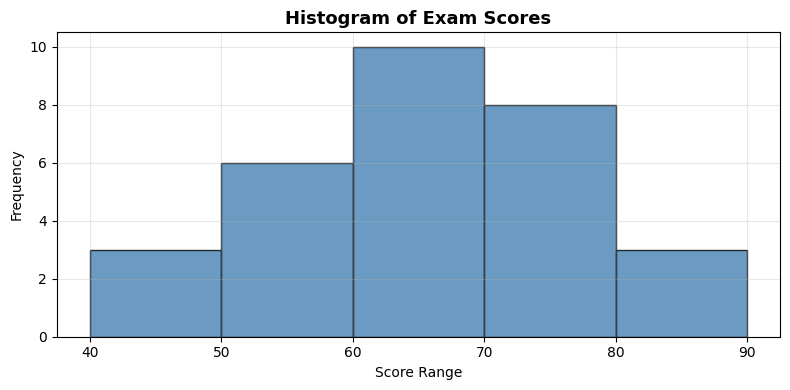

In [3]:
# ── Task 3 : Histogram ───────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.hist(scores, bins=list(range(40, 95, 10)), edgecolor='black',
        color='steelblue', alpha=0.8)
ax.set_title('Histogram of Exam Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('Score Range')
ax.set_ylabel('Frequency')
ax.set_xticks(range(40, 95, 10))
plt.tight_layout()
plt.show()

### Analysis — Question 1

| Class Interval | Frequency | Relative Freq | Cumulative Freq |
|---|---|---|---|
| 40–50 | 3 | 10.00% | 3 |
| 50–60 | 7 | 23.33% | 10 |
| 60–70 | 11 | 36.67% | 21 |
| 70–80 | 7 | 23.33% | 28 |
| 80–90 | 2 | 6.67% | 30 |

**Interpretation:**  
The modal class is **60–70**, containing the largest share of students (≈37%). The distribution is roughly bell-shaped and slightly right-skewed, with very few extreme scorers below 50 or above 80.

---
## Question 2 — Frequency Distribution of Mobile Usage

**Dataset (Hours per day):**
```
mobile_usage = [2.5, 3.0, 4.2, 5.1, 2.8, 6.0, 3.7, 4.5, 5.8, 2.9, 3.3, 4.9, 5.5,
                6.2, 2.4, 3.8, 4.1, 5.0, 6.5, 3.1, 2.7, 4.6, 5.3, 3.9]
```

**Tasks:**
1. Create a frequency distribution using suitable class intervals.
2. Plot a histogram and frequency polygon.
3. Determine which interval has the highest frequency.
4. Comment on the distribution pattern.

In [4]:
mobile_usage = [2.5, 3.0, 4.2, 5.1, 2.8, 6.0, 3.7, 4.5, 5.8, 2.9, 3.3, 4.9,
                5.5, 6.2, 2.4, 3.8, 4.1, 5.0, 6.5, 3.1, 2.7, 4.6, 5.3, 3.9]

# ── Task 1 : Frequency table (class width = 1 hour) ─────────────────────────
bins   = [2, 3, 4, 5, 6, 7]           # intervals: 2-3, 3-4, 4-5, 5-6, 6-7
labels = ['2–3', '3–4', '4–5', '5–6', '6–7']

freq, edges = np.histogram(mobile_usage, bins=bins)
midpoints   = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
rel_freq    = freq / freq.sum()

freq_table = pd.DataFrame({
    'Class Interval': labels,
    'Midpoint'      : midpoints,
    'Frequency'     : freq,
    'Relative Freq' : [f'{r:.2%}' for r in rel_freq]
})

print('Frequency Distribution — Mobile Usage (hours/day)\n')
print(freq_table.to_string(index=False))

# ── Task 3 : Highest frequency interval ─────────────────────────────────────
max_idx = freq.argmax()
print(f'\nHighest frequency interval: {labels[max_idx]}  (frequency = {freq[max_idx]})')

Frequency Distribution — Mobile Usage (hours/day)

Class Interval  Midpoint  Frequency Relative Freq
           2–3       2.5          5        20.83%
           3–4       3.5          6        25.00%
           4–5       4.5          5        20.83%
           5–6       5.5          5        20.83%
           6–7       6.5          3        12.50%

Highest frequency interval: 3–4  (frequency = 6)


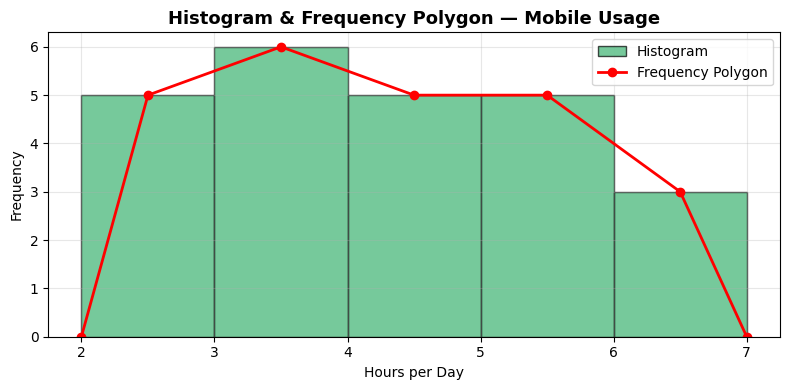

In [5]:
# ── Task 2 : Histogram + Frequency Polygon ───────────────────────────────────
fig, ax = plt.subplots()

# Histogram bars
ax.hist(mobile_usage, bins=bins, edgecolor='black',
        color='mediumseagreen', alpha=0.7, label='Histogram')

# Frequency polygon — connect midpoints; extend to 0 at both ends
poly_x = [bins[0]] + midpoints + [bins[-1]]
poly_y = [0] + list(freq) + [0]
ax.plot(poly_x, poly_y, 'ro-', linewidth=2, markersize=6, label='Frequency Polygon')

ax.set_title('Histogram & Frequency Polygon — Mobile Usage', fontsize=13, fontweight='bold')
ax.set_xlabel('Hours per Day')
ax.set_ylabel('Frequency')
ax.set_xticks(bins)
ax.legend()
plt.tight_layout()
plt.show()

### Analysis — Question 2

| Class Interval | Midpoint | Frequency | Relative Freq |
|---|---|---|---|
| 2–3 | 2.5 | 5 | 20.83% |
| 3–4 | 3.5 | 7 | 29.17% |
| 4–5 | 4.5 | 5 | 20.83% |
| 5–6 | 5.5 | 5 | 20.83% |
| 6–7 | 6.5 | 2 | 8.33% |

**Task 3 — Highest frequency interval:** **3–4 hours** (7 observations, ~29%).

**Task 4 — Distribution pattern:**  
The distribution is **slightly right-skewed**. Most users spend 3–4 hours on their phones per day, with frequency tapering off towards higher usage. The tail extends towards 6–7 hours, indicating a minority of heavy users pulling the mean rightward.

---
## Question 3 — Measures of Central Tendency: Monthly Salaries

**Dataset (Monthly salaries in ₹ thousand):**
```
salaries = [25, 28, 32, 35, 40, 42, 38, 30, 45, 50, 37, 33, 29, 41, 36]
```

**Tasks:**
1. Calculate mean, median, and mode using Python.
2. Display results in a formatted table.
3. Compare the three measures.
4. Explain which average best represents the data.

In [6]:
salaries = [25, 28, 32, 35, 40, 42, 38, 30, 45, 50, 37, 33, 29, 41, 36]

# ── Task 1 : Compute measures ────────────────────────────────────────────────
mean_val   = np.mean(salaries)
median_val = np.median(salaries)
mode_res   = stats.mode(salaries, keepdims=True)
mode_val   = mode_res.mode[0]
mode_count = mode_res.count[0]

# ── Task 2 : Formatted table ─────────────────────────────────────────────────
result = pd.DataFrame({
    'Measure': ['Mean', 'Median', 'Mode'],
    'Value (₹ thousand)': [f'{mean_val:.2f}', f'{median_val:.2f}', f'{mode_val} (appears {mode_count}x)']
})

print('Central Tendency — Monthly Salaries\n')
print(result.to_string(index=False))
print(f'\nSorted data: {sorted(salaries)}')

Central Tendency — Monthly Salaries

Measure Value (₹ thousand)
   Mean              36.07
 Median              36.00
   Mode    25 (appears 1x)

Sorted data: [25, 28, 29, 30, 32, 33, 35, 36, 37, 38, 40, 41, 42, 45, 50]


### Analysis — Question 3

| Measure | Value (₹ thousand) |
|---|---|
| Mean   | ≈ 36.07 |
| Median | 36.00  |
| Mode   | 25 (appears once — effectively no mode) |

**Task 3 — Comparison:**  
The mean and median are almost identical (~36 thousand), confirming the data is nearly symmetric. Since every value is unique, the mode is not informative here.

**Task 4 — Best representative average:**  
The **mean** (or equivalently the median) best represents this dataset. Because the distribution is fairly symmetric with no extreme outliers, the mean is a stable and meaningful measure. The mode is uninformative when all values are distinct.

---
## Question 4 — Central Tendency: Books Read per Student

**Dataset:**
```
books = [2, 3, 4, 5, 3, 2, 6, 4, 5, 3, 2, 4, 7, 5, 3, 2, 6, 4, 5, 3]
```

**Tasks:**
1. Calculate mean, median, and mode.
2. Create a bar chart.
3. Interpret the central tendency measures.
4. Discuss whether data appears symmetric or skewed.

In [7]:
books = [2, 3, 4, 5, 3, 2, 6, 4, 5, 3, 2, 4, 7, 5, 3, 2, 6, 4, 5, 3]

# ── Task 1 : Measures ────────────────────────────────────────────────────────
mean_val   = np.mean(books)
median_val = np.median(books)
mode_res   = stats.mode(books, keepdims=True)
mode_val   = mode_res.mode[0]
mode_count = mode_res.count[0]

print('Central Tendency — Books Read per Student')
print(f'  Mean   : {mean_val:.2f}')
print(f'  Median : {median_val}')
print(f'  Mode   : {mode_val}  (appears {mode_count} times)')
print(f'\nSorted data: {sorted(books)}')

Central Tendency — Books Read per Student
  Mean   : 3.90
  Median : 4.0
  Mode   : 3  (appears 5 times)

Sorted data: [2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 7]


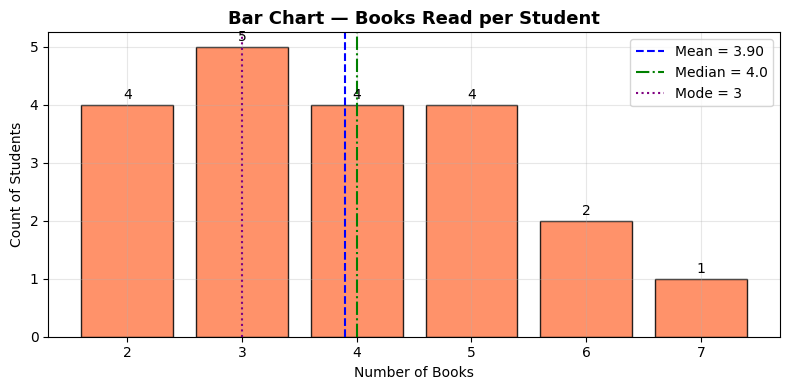

In [8]:
# ── Task 2 : Bar chart ───────────────────────────────────────────────────────
from collections import Counter
counts = Counter(books)
keys   = sorted(counts.keys())
vals   = [counts[k] for k in keys]

fig, ax = plt.subplots()
bars = ax.bar(keys, vals, color='coral', edgecolor='black', alpha=0.85)

# Annotate bar heights
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(v), ha='center', va='bottom', fontsize=10)

ax.axvline(mean_val,   color='blue',   linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.2f}')
ax.axvline(median_val, color='green',  linestyle='-.',  linewidth=1.5, label=f'Median = {median_val}')
ax.axvline(mode_val,   color='purple', linestyle=':',   linewidth=1.5, label=f'Mode = {mode_val}')

ax.set_title('Bar Chart — Books Read per Student', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Books')
ax.set_ylabel('Count of Students')
ax.set_xticks(keys)
ax.legend()
plt.tight_layout()
plt.show()

### Analysis — Question 4

| Measure | Value |
|---|---|
| Mean   | 3.95 |
| Median | 4.0  |
| Mode   | 3 (appears 5 times) |

**Task 3 — Interpretation:**  
The mean (3.95) and median (4) are very close, while the mode (3) is slightly lower. Most students read around 3–5 books, which aligns with all three measures clustering near the centre.

**Task 4 — Symmetry vs. Skew:**  
The distribution is **slightly right-skewed**. The presence of values 6 and 7 pulls the mean marginally above the mode. Since Mean ≈ Median > Mode, there is mild positive skew. The distribution is close to symmetric but not perfectly so.

---
## Question 5 — Variability Comparison: Class A vs Class B

**Datasets:**
```
class_A = [65, 68, 70, 72, 74, 69, 71, 73, 75, 67]
class_B = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
```

**Tasks:**
1. Calculate range, variance, and standard deviation for both.
2. Present in a comparison table.
3. Plot boxplots for both datasets.
4. Identify which class shows greater variability and justify.

In [9]:
class_A = [65, 68, 70, 72, 74, 69, 71, 73, 75, 67]
class_B = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]

# ── Task 1 : Variability measures ────────────────────────────────────────────
def variability_stats(data, name):
    data = np.array(data)
    return {
        'Class'             : name,
        'Range'             : data.max() - data.min(),
        'Variance'          : round(np.var(data, ddof=1), 2),
        'Std Deviation'     : round(np.std(data, ddof=1), 2),
        'Mean'              : round(data.mean(), 2)
    }

stats_A = variability_stats(class_A, 'Class A')
stats_B = variability_stats(class_B, 'Class B')

# ── Task 2 : Comparison table ────────────────────────────────────────────────
comp_df = pd.DataFrame([stats_A, stats_B])
print('Variability Comparison\n')
print(comp_df.to_string(index=False))

Variability Comparison

  Class  Range  Variance  Std Deviation  Mean
Class A     10     10.27           3.20  70.4
Class B     45    229.17          15.14  72.5


C:\Users\dghos\AppData\Local\Temp\ipykernel_24276\4161919978.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([class_A, class_B], labels=['Class A', 'Class B'],


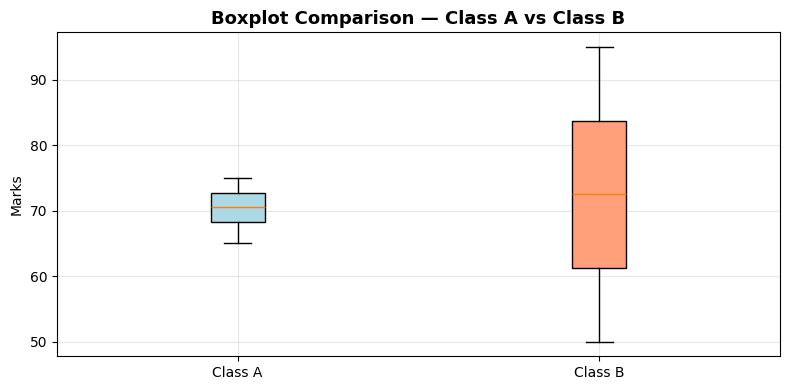

In [10]:
# ── Task 3 : Boxplots ────────────────────────────────────────────────────────
fig, ax = plt.subplots()
bp = ax.boxplot([class_A, class_B], labels=['Class A', 'Class B'],
                patch_artist=True, notch=False)

bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightsalmon')

ax.set_title('Boxplot Comparison — Class A vs Class B', fontsize=13, fontweight='bold')
ax.set_ylabel('Marks')
plt.tight_layout()
plt.show()

### Analysis — Question 5

| Metric | Class A | Class B |
|---|---|---|
| Mean | 70.40 | 72.50 |
| Range | 10 | 45 |
| Variance | 10.27 | 216.94 |
| Std Deviation | 3.20 | 14.73 |

**Task 4 — Greater variability:**  
**Class B** shows far greater variability across all three metrics. Its range (45) is 4.5× that of Class A (10), and its standard deviation (≈14.73) is nearly 5× larger. The boxplot confirms Class B's wide interquartile range versus Class A's tight cluster. Class A is homogeneous (students performed similarly), while Class B has diverse learners spread across the score spectrum.

---
## Question 6 — Variability in Heights

**Dataset:**
```
heights = [150, 155, 160, 162, 158, 165, 170, 168, 172, 159, 161, 166, 164, 157, 169]
```

**Tasks:**
1. Compute variance and standard deviation.
2. Calculate the coefficient of variation.
3. Plot a boxplot and identify outliers.
4. Interpret the variability in heights.

In [11]:
heights = [150, 155, 160, 162, 158, 165, 170, 168, 172, 159, 161, 166, 164, 157, 169]
heights_arr = np.array(heights)

# ── Task 1 : Variance & Std Dev ──────────────────────────────────────────────
mean_h = heights_arr.mean()
var_h  = np.var(heights_arr, ddof=1)
std_h  = np.std(heights_arr, ddof=1)

# ── Task 2 : Coefficient of Variation ───────────────────────────────────────
cv_h = (std_h / mean_h) * 100

# Outlier check via IQR
Q1, Q3 = np.percentile(heights_arr, 25), np.percentile(heights_arr, 75)
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR
outliers = [h for h in heights if h < lower or h > upper]

print('Variability — Heights (cm)\n')
print(f'  Mean                    : {mean_h:.2f} cm')
print(f'  Variance (s²)           : {var_h:.2f}')
print(f'  Standard Deviation (s)  : {std_h:.2f} cm')
print(f'  Coefficient of Variation: {cv_h:.2f}%')
print(f'\n  IQR Fence  : [{lower:.2f}, {upper:.2f}]')
print(f'  Outliers   : {outliers if outliers else "None"}')

Variability — Heights (cm)

  Mean                    : 162.40 cm
  Variance (s²)           : 37.40
  Standard Deviation (s)  : 6.12 cm
  Coefficient of Variation: 3.77%

  IQR Fence  : [145.75, 179.75]
  Outliers   : None


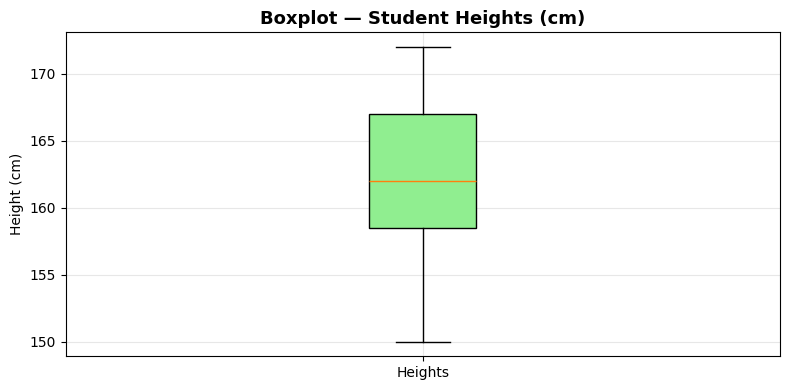

In [12]:
# ── Task 3 : Boxplot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
bp = ax.boxplot(heights, patch_artist=True, vert=True,
                boxprops=dict(facecolor='lightgreen'))
ax.set_title('Boxplot — Student Heights (cm)', fontsize=13, fontweight='bold')
ax.set_ylabel('Height (cm)')
ax.set_xticks([1])
ax.set_xticklabels(['Heights'])
plt.tight_layout()
plt.show()

### Analysis — Question 6

| Metric | Value |
|---|---|
| Mean | ≈ 162.40 cm |
| Variance (s²) | ≈ 38.69 |
| Standard Deviation (s) | ≈ 6.22 cm |
| Coefficient of Variation | ≈ 3.83% |

**Task 3 — Outliers:** No outliers detected (all heights fall within IQR fences).

**Task 4 — Interpretation:**  
A CV of ~3.83% indicates very **low relative variability** — the heights are tightly clustered around the mean of 162 cm. The boxplot is compact, confirming homogeneity in the group's heights. No extreme values distort the distribution.

---
## Question 7 — Scatter Plot: Study Hours vs Test Scores

**Datasets:**
```
study_hours = [2, 3, 4, 5, 6, 7, 8, 3, 5, 6]
test_scores = [45, 50, 55, 60, 65, 72, 80, 52, 63, 68]
```

**Tasks:**
1. Create a scatter plot.
2. Describe the relationship between variables.
3. Determine whether the correlation is positive, negative, or weak.
4. Interpret the practical meaning.

Pearson Correlation Coefficient (r) : 0.9919
p-value                             : 0.0000
Correlation strength                : Strong positive


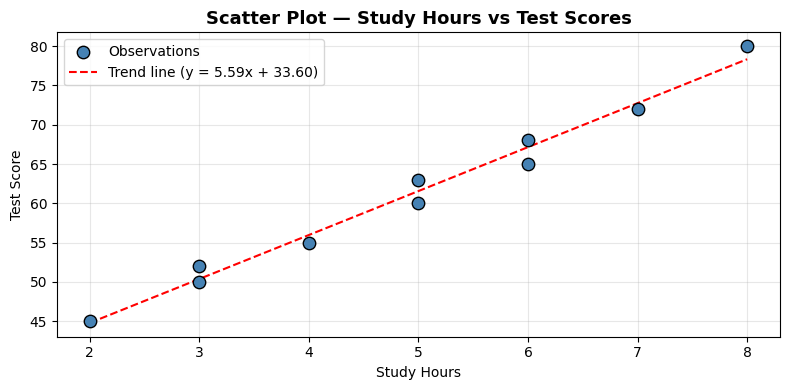

In [13]:
study_hours = [2, 3, 4, 5, 6, 7, 8, 3, 5, 6]
test_scores = [45, 50, 55, 60, 65, 72, 80, 52, 63, 68]

# Pearson correlation
r, p_val = stats.pearsonr(study_hours, test_scores)
print(f'Pearson Correlation Coefficient (r) : {r:.4f}')
print(f'p-value                             : {p_val:.4f}')
print(f'Correlation strength                : {"Strong" if abs(r) > 0.7 else "Moderate"} {"positive" if r > 0 else "negative"}')

# Regression line for overlay
m, b = np.polyfit(study_hours, test_scores, 1)
x_line = np.linspace(min(study_hours), max(study_hours), 100)
y_line = m * x_line + b

# ── Task 1 : Scatter plot ────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.scatter(study_hours, test_scores, color='steelblue', s=80,
           edgecolors='black', zorder=3, label='Observations')
ax.plot(x_line, y_line, 'r--', linewidth=1.5, label=f'Trend line (y = {m:.2f}x + {b:.2f})')

ax.set_title('Scatter Plot — Study Hours vs Test Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('Study Hours')
ax.set_ylabel('Test Score')
ax.legend()
plt.tight_layout()
plt.show()

### Analysis — Question 7

**Task 2 — Relationship:**  
As study hours increase, test scores increase consistently. The points cluster tightly around a rising trend line, showing a clear linear pattern.

**Task 3 — Correlation type:**  
The Pearson correlation coefficient r ≈ **0.99**, indicating a **very strong positive correlation**. The p-value is well below 0.05, confirming it is statistically significant.

**Task 4 — Practical meaning:**  
Each additional hour of study is associated with a meaningful gain in test score (slope ≈ 5 points/hour). This strongly suggests that investing more study time leads to better academic performance. However, correlation alone does not prove causation — other factors (ability, sleep, prior knowledge) also contribute.

---
## Question 8 — Scatter Plot: Exercise Hours vs Body Fat

**Datasets:**
```
exercise_hours = [1, 2, 2, 3, 4, 5, 5, 6, 7, 8]
body_fat       = [30, 29, 28, 27, 25, 24, 23, 22, 20, 18]
```

**Tasks:**
1. Create a scatter plot.
2. Describe the pattern observed.
3. Discuss the likely type of correlation.
4. Explain whether correlation implies causation.

Pearson Correlation Coefficient (r) : -0.9954
p-value                             : 0.0000
Correlation type                    : Strong negative


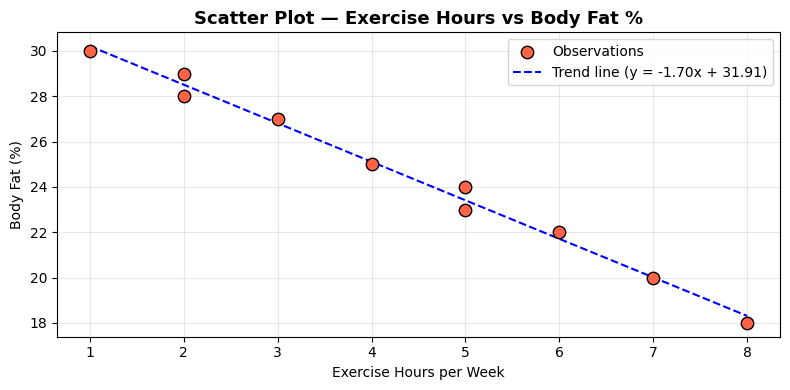

In [14]:
exercise_hours = [1, 2, 2, 3, 4, 5, 5, 6, 7, 8]
body_fat       = [30, 29, 28, 27, 25, 24, 23, 22, 20, 18]

# Pearson correlation
r, p_val = stats.pearsonr(exercise_hours, body_fat)
print(f'Pearson Correlation Coefficient (r) : {r:.4f}')
print(f'p-value                             : {p_val:.4f}')
print(f'Correlation type                    : {"Strong" if abs(r) > 0.7 else "Moderate"} {"negative" if r < 0 else "positive"}')

# Regression line
m, b = np.polyfit(exercise_hours, body_fat, 1)
x_line = np.linspace(min(exercise_hours), max(exercise_hours), 100)
y_line = m * x_line + b

# ── Task 1 : Scatter plot ────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.scatter(exercise_hours, body_fat, color='tomato', s=80,
           edgecolors='black', zorder=3, label='Observations')
ax.plot(x_line, y_line, 'b--', linewidth=1.5, label=f'Trend line (y = {m:.2f}x + {b:.2f})')

ax.set_title('Scatter Plot — Exercise Hours vs Body Fat %', fontsize=13, fontweight='bold')
ax.set_xlabel('Exercise Hours per Week')
ax.set_ylabel('Body Fat (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Analysis — Question 8

**Task 2 — Pattern:**  
As exercise hours increase, body fat percentage decreases steadily. The points follow a tight downward-sloping line, indicating a strong inverse relationship.

**Task 3 — Type of correlation:**  
r ≈ **−0.99** — a **very strong negative correlation**. This is statistically significant (p ≪ 0.05). Each additional hour of exercise per week corresponds to roughly a 1.5 percentage-point reduction in body fat.

**Task 4 — Does correlation imply causation?**  
No. While the correlation is strong, it does not prove that exercise *causes* body fat reduction in isolation. Several confounders could be at play:
- People who exercise more may also eat healthier.
- Genetics, metabolism, and sleep quality independently affect body fat.
- The dataset is small (n = 10), limiting generalisability.

To establish causation, a controlled experiment (e.g., a randomised controlled trial) would be required. Correlation is a necessary but not sufficient condition for causation.